# Análisis Exploratorio - Sentinel 2 (NDVI y NDBI)
Este notebook explora los índices de vegetación (NDVI) y urbanización (NDBI).

In [8]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

In [9]:
def plot_sentinel(filepath):
    with rasterio.open(filepath) as src:
        # Band 1: NDVI (Vegetación), Band 2: NDBI (Urbanización)
        # (Si al visualizar notas que los colores están al revés, 
        # simplemente intercambia los índices de read(1) y read(2))
        ndvi = src.read(1)
        ndbi = src.read(2)
        
        # Enmascarar valores atípicos o nodata
        ndvi = np.where(ndvi < -1, np.nan, ndvi)
        ndbi = np.where(ndbi < -1, np.nan, ndbi)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # NDVI: Verde es mucha vegetación, rojo/marrón es poca (o suelo desnudo)
        im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
        ax1.set_title(f'NDVI (Vegetación)\n{os.path.basename(filepath)}')
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.axis('off')
        
        # NDBI: Rojo es asfalto/ciudad, azul es vegetación/agua
        im2 = ax2.imshow(ndbi, cmap='coolwarm', vmin=-0.2, vmax=0.4)
        ax2.set_title(f'NDBI (Urbanización)\n{os.path.basename(filepath)}')
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        ax2.axis('off')
        
        plt.tight_layout()
        plt.show()

--- ANTES DEL INCENDIO (Q2 2023) ---


C:\Users\ROBERTO\AppData\Local\Temp\ipykernel_14656\3892756799.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndvi = src.read(1)
C:\Users\ROBERTO\AppData\Local\Temp\ipykernel_14656\3892756799.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndbi = src.read(2)


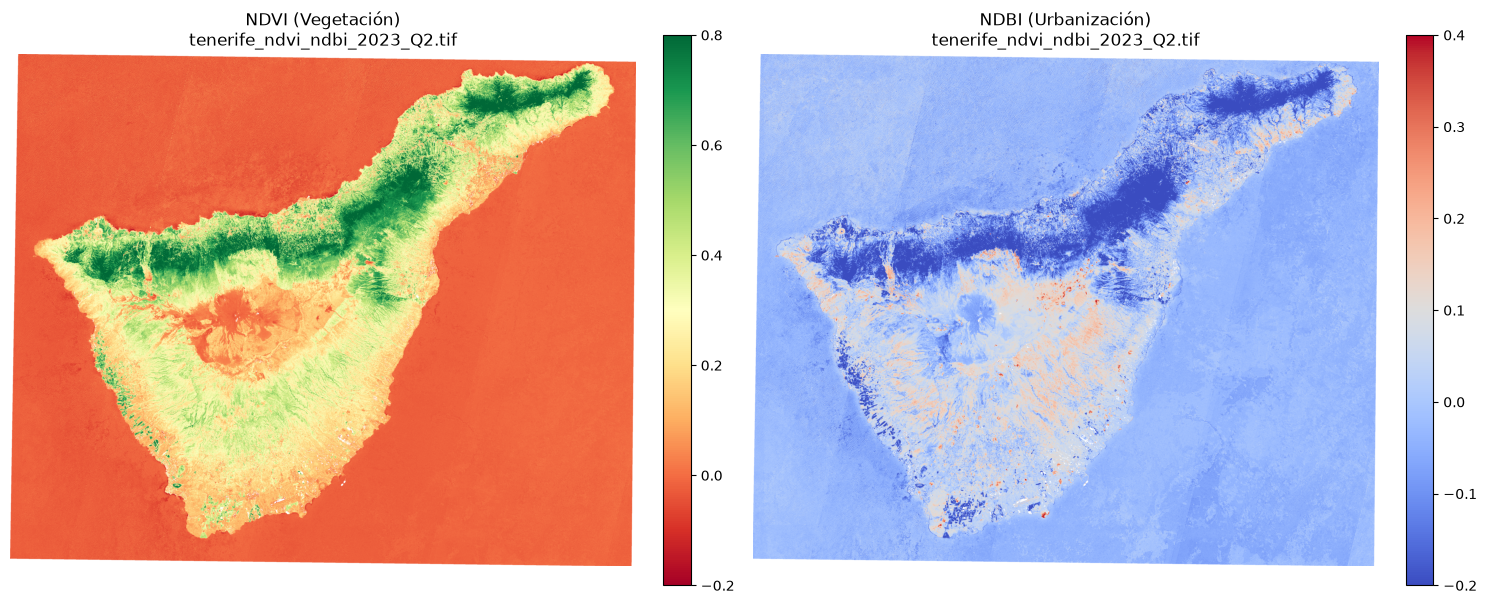

--- DESPUÉS DEL INCENDIO (Q4 2023) ---


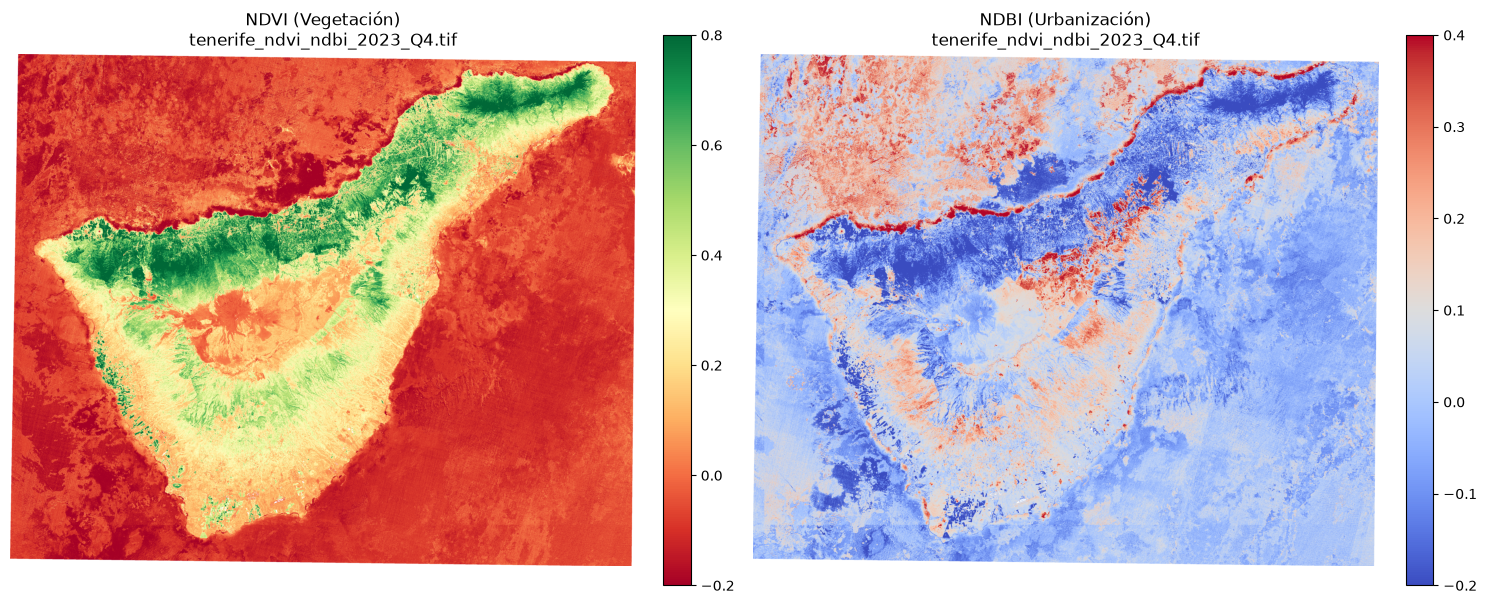

In [10]:
# Comparar vegetación (NDVI) ANTES y DESPUÉS del incendio de agosto 2023
# El incendio ocurrió en Q3 2023. Comparamos Q2 (antes) con Q4 (después).
file_antes = '../data/Satelite_Sentinel2/tenerife_ndvi_ndbi_2023_Q2.tif'
file_despues = '../data/Satelite_Sentinel2/tenerife_ndvi_ndbi_2023_Q4.tif'

if os.path.exists(file_antes) and os.path.exists(file_despues):
    print("--- ANTES DEL INCENDIO (Q2 2023) ---")
    plot_sentinel(file_antes)
    print("--- DESPUÉS DEL INCENDIO (Q4 2023) ---")
    plot_sentinel(file_despues)
else:
    print('Archivos no encontrados')

## 2. Validación Estadística (Histogramas para detección de ruido)
Para comprobar si las imágenes tienen demasiado ruido (nubes gruesas, sombras profundas), generamos un histograma. Un histograma bimodal saludable (un pico para roca/asfalto y otro para bosques) indica que la imagen está bien enmascarada.

--- ANÁLISIS ESTADÍSTICO: ANTES DEL INCENDIO (Q2 2023) ---


C:\Users\ROBERTO\AppData\Local\Temp\ipykernel_14656\2891088624.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndvi = src.read(1).flatten()
C:\Users\ROBERTO\AppData\Local\Temp\ipykernel_14656\2891088624.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndbi = src.read(2).flatten()


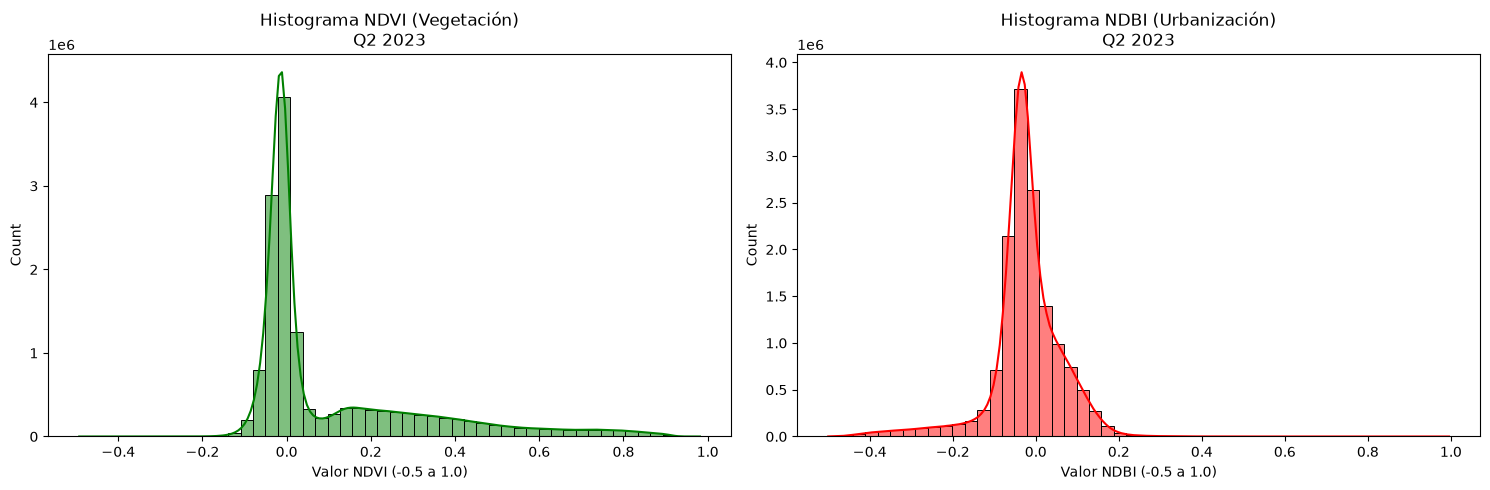

--- ANÁLISIS ESTADÍSTICO: DESPUÉS DEL INCENDIO (Q4 2023) ---


C:\Users\ROBERTO\AppData\Local\Temp\ipykernel_14656\2891088624.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndvi = src.read(1).flatten()
C:\Users\ROBERTO\AppData\Local\Temp\ipykernel_14656\2891088624.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ndbi = src.read(2).flatten()


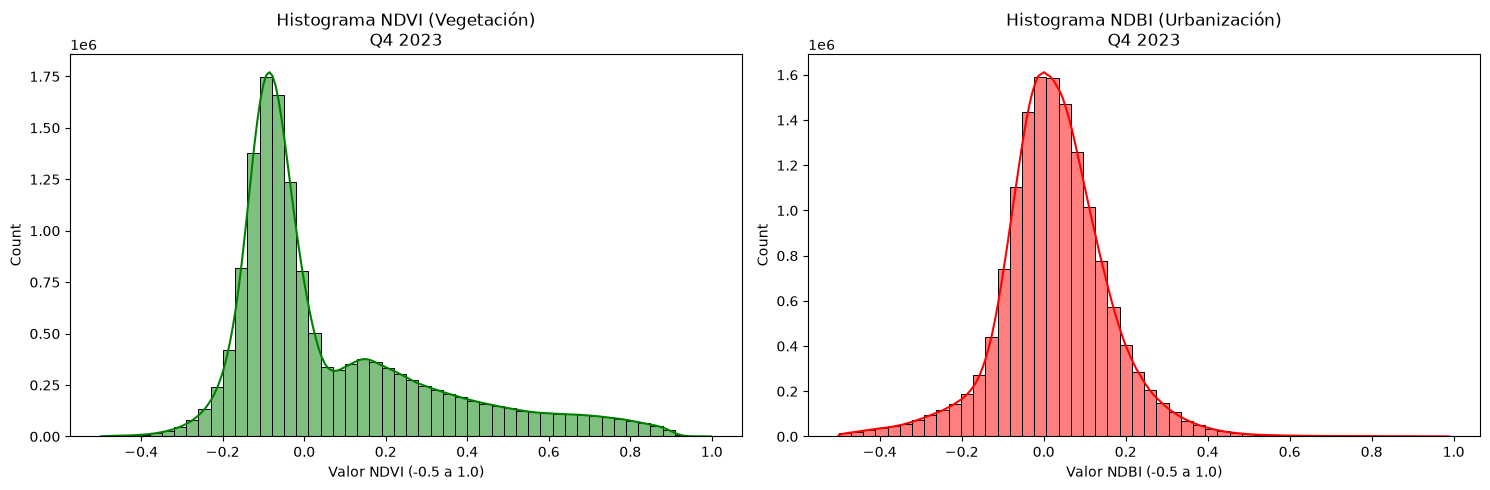

In [11]:
import seaborn as sns

def plot_histogram(filepath, title):
    with rasterio.open(filepath) as src:
        # Aplanamos la matriz 2D a una lista 1D para el histograma
        ndvi = src.read(1).flatten()
        ndbi = src.read(2).flatten()
        
        # Filtramos los valores "NoData" del mar y errores (los que son -1 o menores)
        # Nos quedamos solo con los píxeles útiles de la isla
        ndvi_valid = ndvi[(ndvi > -0.5) & (ndvi < 1.0)]
        ndbi_valid = ndbi[(ndbi > -0.5) & (ndbi < 1.0)]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        sns.histplot(ndvi_valid, bins=50, ax=ax1, color='green', kde=True)
        ax1.set_title(f'Histograma NDVI (Vegetación)\n{title}')
        ax1.set_xlabel('Valor NDVI (-0.5 a 1.0)')
        
        sns.histplot(ndbi_valid, bins=50, ax=ax2, color='red', kde=True)
        ax2.set_title(f'Histograma NDBI (Urbanización)\n{title}')
        ax2.set_xlabel('Valor NDBI (-0.5 a 1.0)')
        
        plt.tight_layout()
        plt.show()

# Ejecutamos el análisis estadístico para el trimestre ANTES del incendio
file_antes = '../data/Satelite_Sentinel2/tenerife_ndvi_ndbi_2023_Q2.tif'
file_despues = '../data/Satelite_Sentinel2/tenerife_ndvi_ndbi_2023_Q4.tif'

if os.path.exists(file_antes):
    print("--- ANÁLISIS ESTADÍSTICO: ANTES DEL INCENDIO (Q2 2023) ---")
    plot_histogram(file_antes, 'Q2 2023')
    
if os.path.exists(file_despues):
    print("--- ANÁLISIS ESTADÍSTICO: DESPUÉS DEL INCENDIO (Q4 2023) ---")
    plot_histogram(file_despues, 'Q4 2023')
